<a href="https://colab.research.google.com/github/Koginitiv-Analytics/supply-chain-logistics-intelligence/blob/main/02_end_to_end_supply_chain_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.12k/9.12k [00:00<00:00, 4.20MB/s]

Extracting files...
Dataset Shape: 100 Rows | 24 Columns



  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai        29          

/tmp/ipykernel_2429/859972509.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2429/859972509.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


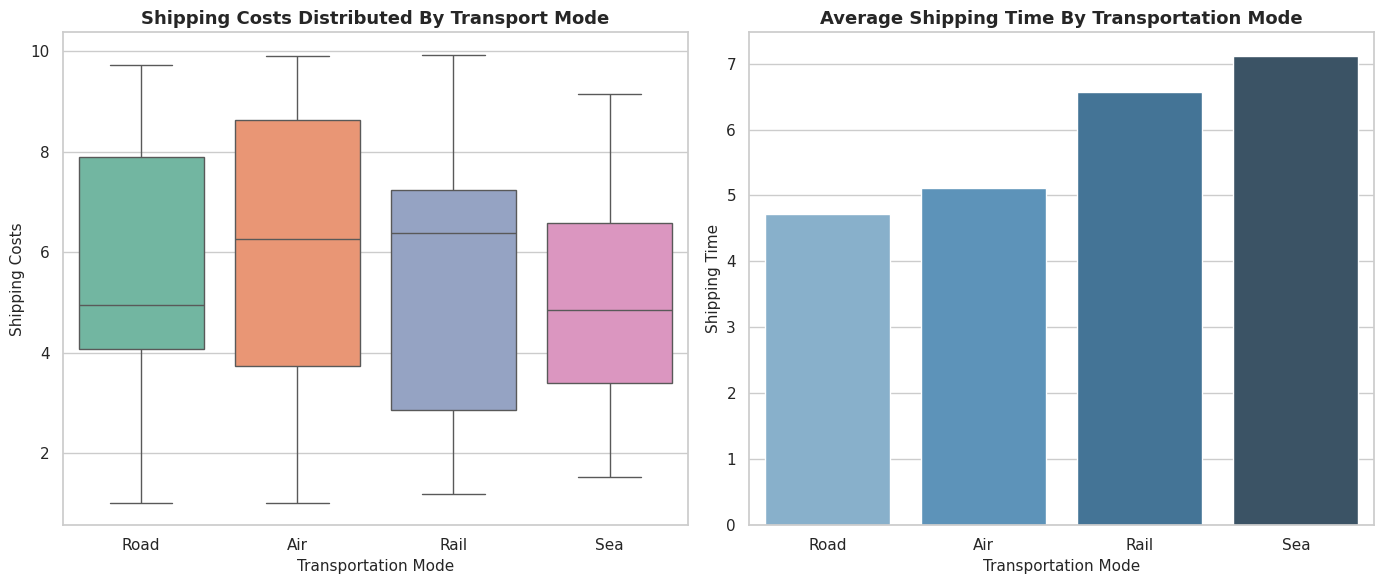

Transportation Mode Performance Summary
  transportation_modes  avg_shipping_cost  avg_shipping_time  total_revenue
0                  Air           6.017839           5.115385  155735.349650
1                 Rail           5.469098           6.571429  164990.417667
2                 Road           5.542115           4.724138  159315.232239
3                  Sea           4.970294           7.117647   97563.819181


/tmp/ipykernel_2429/859972509.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


---Supplier Risk Metrics---
  supplier_name  avg_defect_rate  avg_mfg_cost  avg_lead_time
0    Supplier 1         1.803630     45.254027      14.777778
1    Supplier 2         2.362750     41.622514      18.545455
2    Supplier 3         2.465786     43.634121      20.133333
3    Supplier 4         2.337397     62.709727      15.222222
4    Supplier 5         2.665408     44.768243      18.055556


/tmp/ipykernel_2429/859972509.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


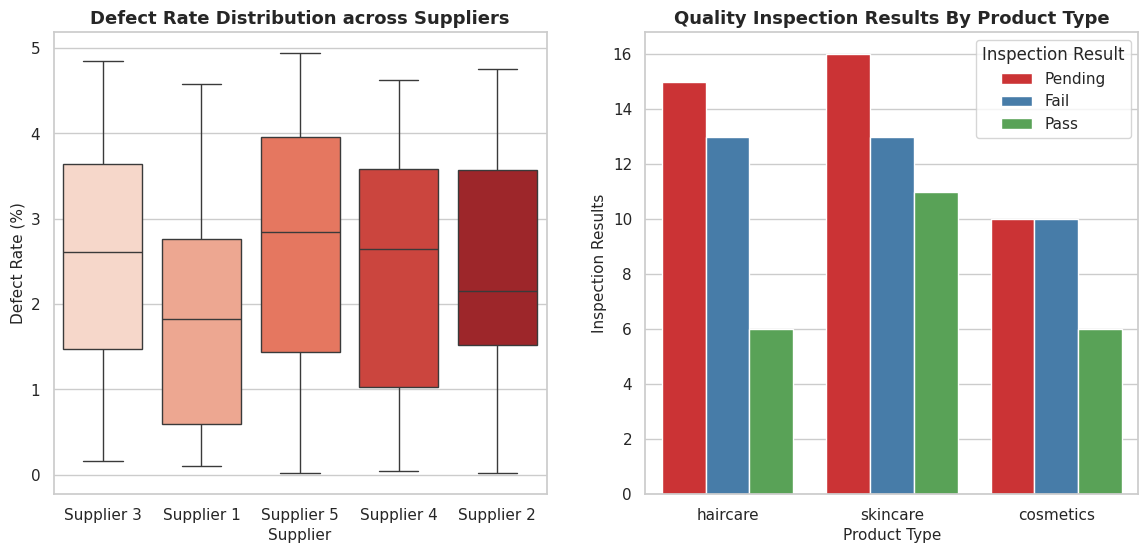

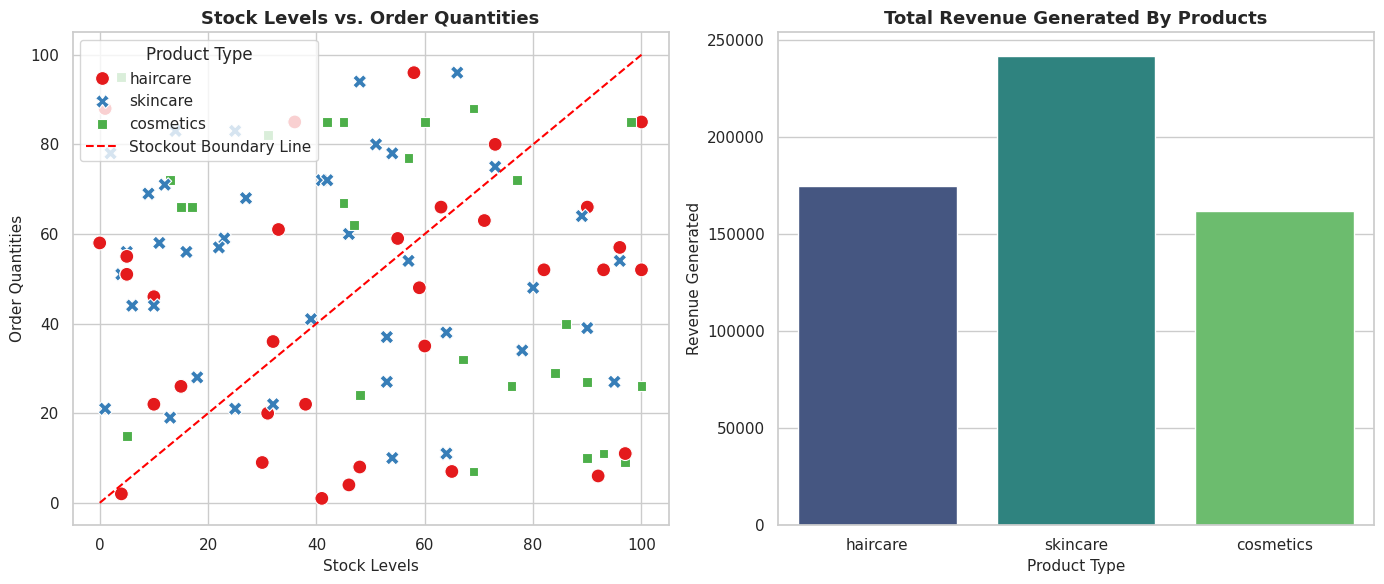

---INVENTORY STOCKOUT & REVENUE RISK SUMMARY---
  product_type  total_orders  stockout_risk_count  total_revenue  \
0    cosmetics            26                   13  161521.265999   
1     haircare            34                   15  174455.390605   
2     skincare            40                   26  241628.162133   

   stockout_risk_ratio %  
0              50.000000  
1              44.117647  
2              65.000000  
Accuracy Score: 55.00%

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         9
           1       0.57      0.73      0.64        11

    accuracy                           0.55        20
   macro avg       0.54      0.53      0.52        20
weighted avg       0.54      0.55      0.53        20



/tmp/ipykernel_2429/859972509.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')


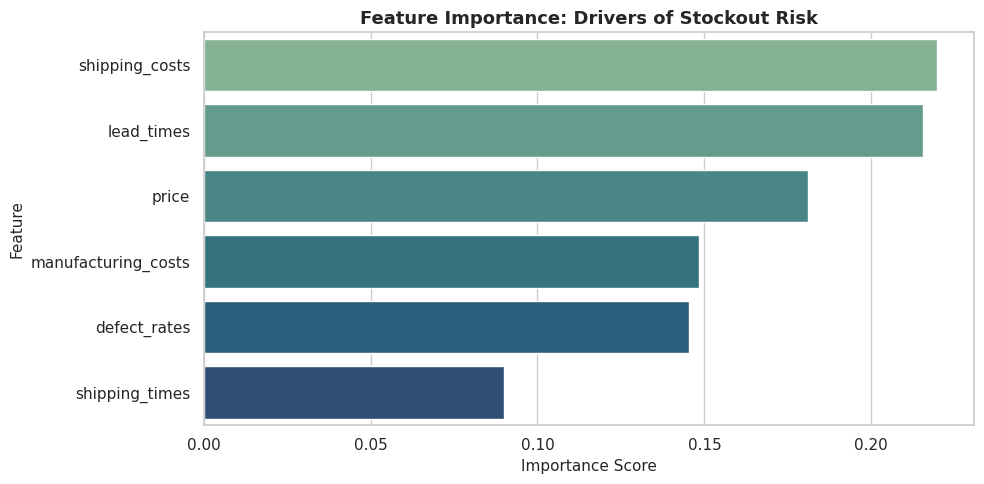

--- IMPROVED MODEL ACCURACY & PERFORMANCE ---
New Accuracy Score: 60.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.33      0.43         9
           1       0.60      0.82      0.69        11

    accuracy                           0.60        20
   macro avg       0.60      0.58      0.56        20
weighted avg       0.60      0.60      0.57        20



/tmp/ipykernel_2429/859972509.py:251: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


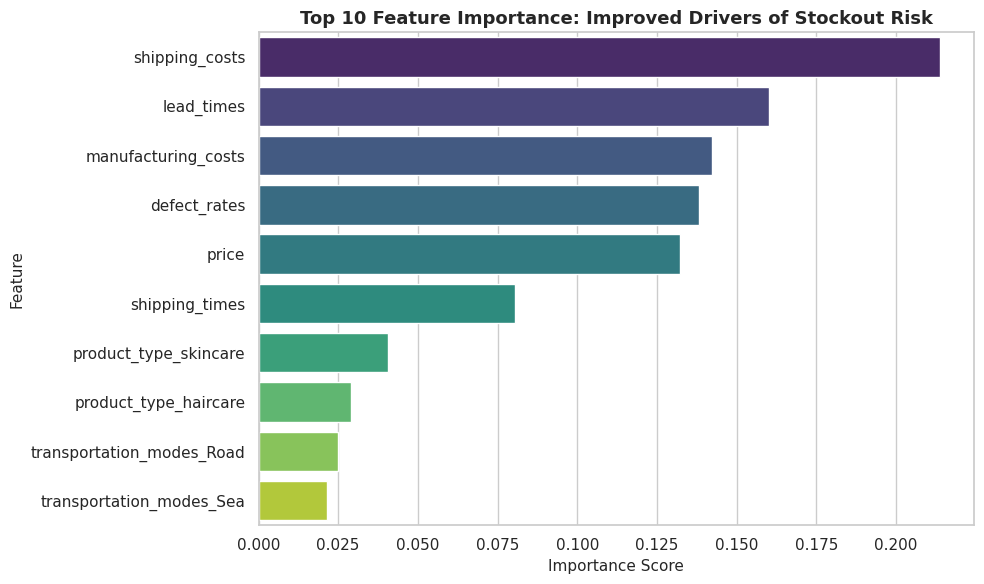

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

path = kagglehub.dataset_download("harshsingh2209/supply-chain-analysis")

csv_path = os.path.join(path, "supply_chain_data.csv")

df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape[0]} Rows | {df.shape[1]} Columns\n")
print(df.head())

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


print("---Null Values---")
print(df.isnull().sum())


df['total_cost'] = df['manufacturing_costs'] + df['shipping_costs']


df['profit'] = df['revenue_generated'] - df['total_cost']


df['profit_margin_pct'] = (df['profit'] / df['revenue_generated']) * 100


df['total_lead_time'] = df['manufacturing_lead_time'] + df['lead_time']



kpi_cols = ['product_type', 'supplier_name', 'transportation_modes', 'total_cost', 'revenue_generated', 'profit_margin_pct', 'total_lead_time']

print(df[kpi_cols].head())

print(f"\nDataset Shape: {df.shape[0]} Rows | {df.shape[1]} Columns")

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.boxplot(
    data=df,
    x='transportation_modes',
    y='shipping_costs',
    palette='Set2'
)

plt.title("Shipping Costs Distributed By Transport Mode", fontsize=13, fontweight='bold')
plt.xlabel("Transportation Mode", fontsize=11)
plt.ylabel("Shipping Costs", fontsize=11)

plt.subplot(1, 2, 2)
sns.barplot(
    data=df,
    x='transportation_modes',
    y='shipping_times',
    palette='Blues_d',
    errorbar=None
)

plt.title("Average Shipping Time By Transportation Mode", fontsize=13, fontweight='bold')
plt.xlabel("Transportation Mode", fontsize=11)
plt.ylabel("Shipping Time", fontsize=11)

plt.tight_layout()
plt.show()

mode_summary = df.groupby('transportation_modes').agg(
   avg_shipping_cost=('shipping_costs', 'mean'),
   avg_shipping_time=('shipping_times', 'mean'),
   total_revenue=('revenue_generated', 'sum')
).reset_index()

print("Transportation Mode Performance Summary")
print(mode_summary)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(
    data=df,
    x='supplier_name',
    y='defect_rates',
    palette='Reds'
)

plt.title('Defect Rate Distribution across Suppliers', fontsize=13, fontweight='bold')
plt.xlabel('Supplier', fontsize=11)
plt.ylabel('Defect Rate (%)', fontsize=11)


plt.subplot(1, 2, 2)
sns.countplot(
    data=df,
    x='product_type',
    hue='inspection_results',
    palette='Set1'
)

plt.title('Quality Inspection Results By Product Type', fontsize=13, fontweight='bold')
plt.xlabel('Product Type', fontsize=11)
plt.ylabel('Inspection Results', fontsize=11)
plt.legend(title='Inspection Result')

supplier_risk = df.groupby('supplier_name').agg(
    avg_defect_rate=('defect_rates', 'mean'),
    avg_mfg_cost=('manufacturing_costs', 'mean'),
    avg_lead_time=('lead_time', 'mean')
).reset_index()

print("---Supplier Risk Metrics---")
print(supplier_risk)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x='stock_levels',
    y='order_quantities',
    hue='product_type',
    style='product_type',
    s=100,
    palette='Set1'
)

plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Stockout Boundary Line')
plt.title('Stock Levels vs. Order Quantities', fontsize=13, fontweight='bold')
plt.xlabel('Stock Levels', fontsize=11)
plt.ylabel('Order Quantities', fontsize=11)
plt.legend(title='Product Type')

plt.subplot(1, 2, 2)
sns.barplot(
    data=df,
    x='product_type',
    y='revenue_generated',
    palette='viridis',
    estimator=sum,
    errorbar=None
)

plt.title('Total Revenue Generated By Products', fontsize=13, fontweight='bold')
plt.xlabel('Product Type', fontsize=11)
plt.ylabel('Revenue Generated', fontsize=11)

plt.tight_layout()
plt.show()

df['stock_risk'] = df['order_quantities'] > df['stock_levels']

stockout_summary = df.groupby('product_type').agg(
    total_orders=('order_quantities', 'count'),
    stockout_risk_count=('stock_risk', 'sum'),
    total_revenue=('revenue_generated', 'sum')
).reset_index()

stockout_summary['stockout_risk_ratio %'] = (stockout_summary['stockout_risk_count'] / stockout_summary['total_orders']) * 100

print("---INVENTORY STOCKOUT & REVENUE RISK SUMMARY---")
print(stockout_summary)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df['target_stockout'] = (df['order_quantities'] > df['stock_levels']).astype(int)


feature_cols = [
    'price',
    'lead_times',
    'manufacturing_costs',
    'defect_rates',
    'shipping_costs',
    'shipping_times'
]

X = df[feature_cols]
y = df['target_stockout']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='crest')
plt.title('Feature Importance: Drivers of Stockout Risk', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


df_encoded = pd.get_dummies(df, columns=['product_type', 'transportation_modes'], drop_first=True)

feature_cols = [
    'price', 'lead_times', 'manufacturing_costs',
    'defect_rates', 'shipping_costs', 'shipping_times'
] + [col for col in df_encoded.columns if col.startswith(('product_type_', 'transportation_modes_'))]

X = df_encoded[feature_cols]
y = df_encoded['target_stockout']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=4,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- IMPROVED MODEL ACCURACY & PERFORMANCE ---")
print(f"New Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance: Improved Drivers of Stockout Risk', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()